In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

In [8]:
df = pd.read_csv("movies.csv")

In [9]:
df["success"] = (df["revenue"] > df["budget"]).astype(int)

In [10]:
X = df[['budget', 'popularity', 'runtime', 'vote_average']]
y = df['success']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.785
Precision: 0.7964376590330788
Recall: 0.9811912225705329
              precision    recall  f1-score   support

           0       0.14      0.01      0.02        81
           1       0.80      0.98      0.88       319

    accuracy                           0.79       400
   macro avg       0.47      0.50      0.45       400
weighted avg       0.66      0.79      0.71       400

[[  1  80]
 [  6 313]]


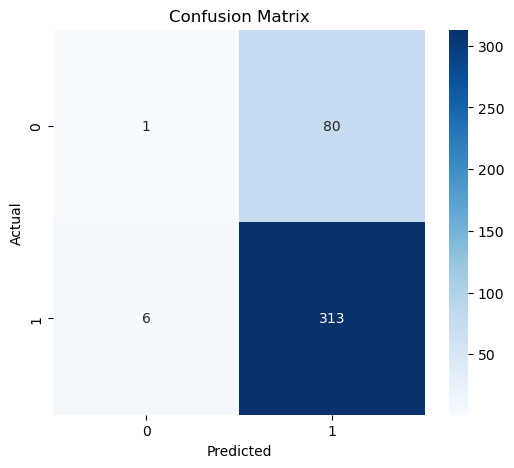

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

        Feature  Importance
1    popularity    0.270826
0        budget    0.262001
3  vote_average    0.261316
2       runtime    0.205857


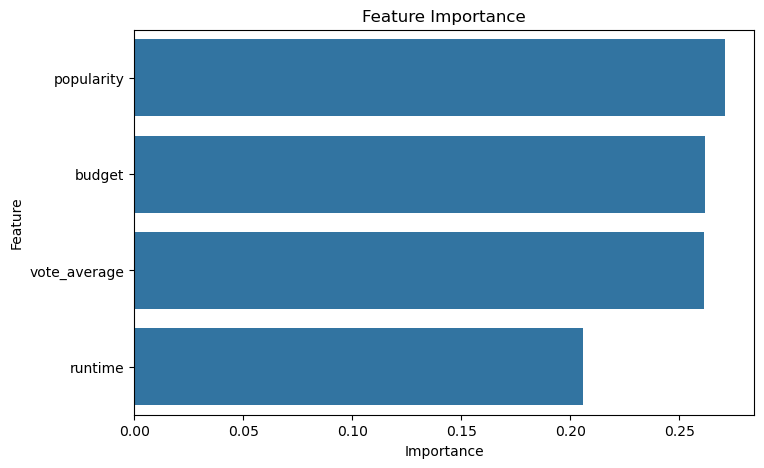

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()